In [1]:
from simulation import *
from math import *
import matplotlib.pyplot as plt
import numpy as np
from viz_io import save_or_show_fig

glass_nk = 1.5 + 0j
air_nk   = 1 + 0j
glass = make_layer_from_nk_s(glass_nk, 0.0, "glass")
air = make_layer_from_nk_s(air_nk, 0.0, "air")


def show_curves(curves, start_x, step_x, *, legends=None, types=None, title="Curves", xlabel="X", ylabel="Y"):
    n = len(curves)
    if legends is None:
        legends = [f"Curve {i}" for i in range(n)]
    if types is None:
        types = ["-"] * n
    fig, ax = plt.subplots()
    for i in range(n):
        y = np.asarray(curves[i], dtype=float)
        x = np.array([start_x[i] + j * step_x[i] for j in range(len(y))])
        ax.plot(x, y, types[i], label=legends[i])
    ax.legend(loc="upper right")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True)
    save_or_show_fig(fig, title=title)

def test_TMM_interface_matrix(layers, N = 90, wl_um = 0.550):
    meterials = TMM_resolve_nk_depth_at_wl_s(layers, float(wl_um))
    for i, m in enumerate(meterials):
        print(i, m.background_material.nk_at_wavelength_um(float(wl_um)), m.depth)
    
    step = 0.5 * pi / (N - 1)
    eps = 1e-6
    rs_power = list()
    ts_power = list()
    rp_power = list()
    tp_power = list()
    rs_real_part = list()
    ts_real_part = list()
    rp_real_part = list()
    tp_real_part = list()

    phase_rs = list()
    phase_rp = list()
    for i in range(N):
        crao = i * step + 0j
        dir = TMM_propagate_direction_s(meterials, crao, float(wl_um))
        tmm = TMM_interface_transfer_matrix_s(meterials, dir, float(wl_um))
        Rs, Ts = TMM_get_r_t_power_from_tmm_s(tmm[0], meterials[0].background_material.nk_at_wavelength_um(float(wl_um)), dir[0], meterials[1].background_material.nk_at_wavelength_um(float(wl_um)), dir[1])
        assert(TMM_check_power_refrection_transmission_s(Rs, Ts, eps))
        rs_power.append(Rs)
        ts_power.append(Ts)

        rs, ts = TMM_get_r_t_from_tmm(tmm[0])
        assert(TMM_check_refrection_transmission_s(rs, ts, meterials[0].background_material.nk_at_wavelength_um(float(wl_um)), meterials[1].background_material.nk_at_wavelength_um(float(wl_um)), eps))
        rs_real_part.append(rs.real)
        ts_real_part.append(ts.real)
        
        tmm = TMM_interface_transfer_matrix_p(meterials, dir, float(wl_um))
        Rp, Tp = TMM_get_r_t_power_from_tmm_p(tmm[0], meterials[0].background_material.nk_at_wavelength_um(float(wl_um)), dir[0], meterials[1].background_material.nk_at_wavelength_um(float(wl_um)), dir[1])
        assert(TMM_check_power_refrection_transmission_p(Rp, Tp, eps))
        rp_power.append(Rp)
        tp_power.append(Tp)

        rp, tp = TMM_get_r_t_from_tmm(tmm[0])
        assert(TMM_check_refrection_transmission_p(rp, tp, meterials[0].background_material.nk_at_wavelength_um(float(wl_um)), meterials[1].background_material.nk_at_wavelength_um(float(wl_um)), eps))
        rp_real_part.append(rp.real)
        tp_real_part.append(tp.real)

        phase_rs.append(np.abs(np.angle(rs, deg=True)))
        phase_rp.append(np.abs(np.angle(rp, deg=True)))

    unpolarized_reflection_power = [(a+b)/2 for a,b in zip(rp_power, rs_power)]
    unpolarized_transimition_power = [(a+b)/2 for a,b in zip(tp_power, ts_power)]

    return {
        "wl_um": wl_um,
        "meterials": meterials,
        "rs_power" : rs_power,
        "ts_power" : ts_power,
        "rp_power" : rp_power,
        "tp_power" : tp_power,
        "rs" : rs_real_part,
        "ts" : ts_real_part,
        "rp" : rp_real_part,
        "tp" : tp_real_part,
        "unpolarized_reflection_power" : unpolarized_reflection_power,
        "unpolarized_transimition_power" : unpolarized_transimition_power,
        "phase_rs": phase_rs,
        "phase_rp": phase_rp,
    }
def plot_result(result, with_unpolarized = False):
    N = len(result["rs_power"])
    curves = [result["rs_power"], result["ts_power"], 
              result["rp_power"], result["tp_power"],
    ]
    if with_unpolarized:
        for r in ["unpolarized_reflection_power", "unpolarized_transimition_power"]:
            curves.append(result[r])

    start_x = [0 for i in range(len(curves))]
    step_x  = [90.0/(N - 1) for i in range(len(curves))]
    legends = ["R_s", "T_s", "R_p", "T_p", "R_unpolarized", "T_unpolarized"]
    style   = ["b--", "b-", "r--", "r-", "c.", "y."]

    print("* power of reflection & transimition")
    show_curves(curves, start_x, step_x, legends=legends, types=style, title="RT_power")
    
    print("* reflection & transimition")
    curves = [
        result["rs"], result["ts"],
        result["rp"], result["tp"],
    ]
    start_x = [0 for i in range(len(curves))]
    step_x  = [90.0/(N - 1) for i in range(len(curves))]
    legends = ["rs", "ts", "rp", "tp"]
    style   = ["b--", "b-", "r--", "r-"]
    show_curves(curves, start_x, step_x, legends=legends, types=style, title="RT_coeff")


* glass to air
0 (1.5+0j) 0.0
1 (1+0j) 0.0
* power of reflection & transimition


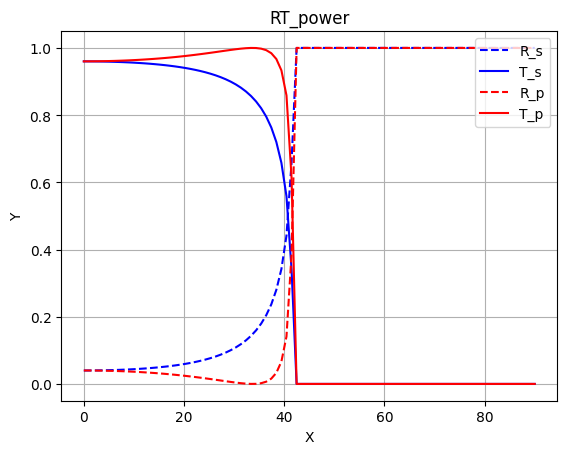

* reflection & transimition


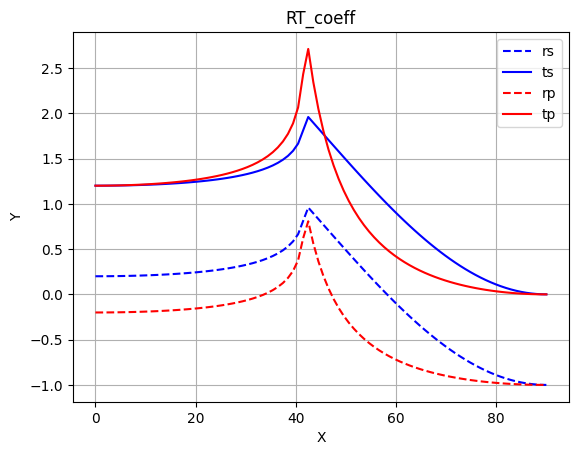

In [2]:
print("* glass to air")
def glass_to_air():
    return [glass, air]
result_glass_to_air = test_TMM_interface_matrix(glass_to_air(), 90)
plot_result(result_glass_to_air, with_unpolarized=False)


- golden result from wikipedia
<div style="display: flex; justify-content: space-around;">
    <img src="../resource/Fresnel_power_glass-to-air.svg" alt="Fresnel_power_glass-to-air" width="48%">
    <img src="../resource/Fresnel_amplitudes_glass-to-air.svg" alt="Fresnel_amplitudes_glass-to-air" width="48%">
</div>


* air to glass
0 (1+0j) 0.0
1 (1.5+0j) 0.0
* power of reflection & transimition


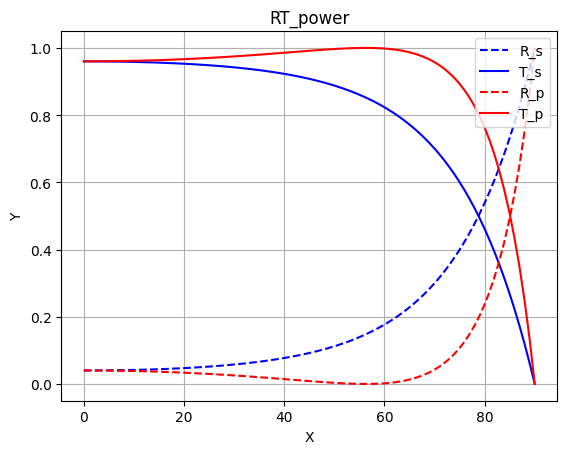

* reflection & transimition


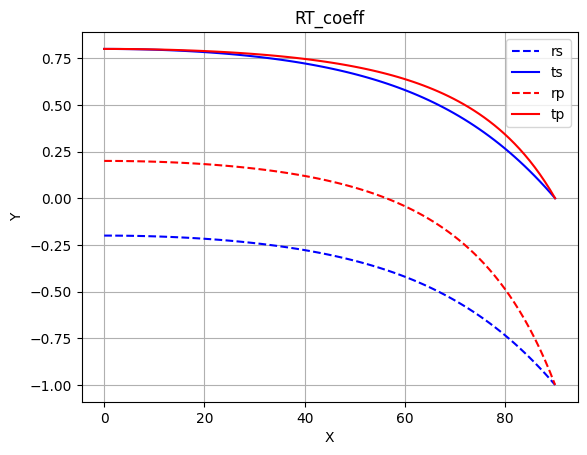

In [3]:
print("* air to glass")
def air_to_glass():
    return [air, glass]
result_air_to_glass = test_TMM_interface_matrix(air_to_glass(), 90)
plot_result(result_air_to_glass, with_unpolarized=False)

- golden result from wikipedia

<div style="display: flex; justify-content: space-around;">
    <img src="../resource/Fresnel_power_air-to-glass.svg" alt="Fresnel_amplitudes_air-to-glass" width="48%">
    <img src="../resource/Fresnel_amplitudes_air-to-glass.svg" alt="Fresnel_power_air-to-glass" width="48%">
</div>

* phase from air to glass
  brewster angle is 56.309932474020215


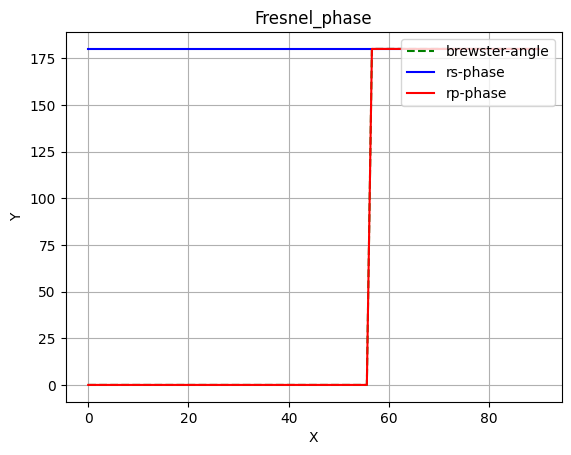

* phase from glass to air
  brewster angle is 33.690067525979785
  critical angle is 41.810314895778596
  max delta-phase is 45.23871612744304


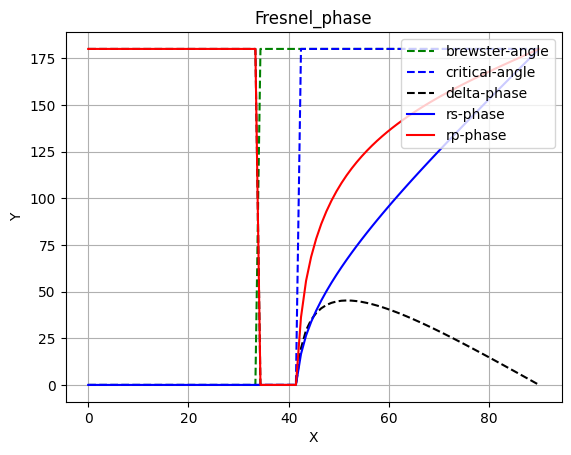

In [4]:
def brewster_angle(n0, n1):
    return 180 / pi *atan(n1/n0)
def total_internal_reflection_angle(n0, n1):
    if n1 < n0: return 180 / pi *asin(n1/n0)
    return 0

def plot_phase(result, plot_meta):
    if plot_meta:
        nk_list = [np.real(m.background_material.nk_at_wavelength_um(float(result["wl_um"]))) for m in result["meterials"]]
        brewster = brewster_angle(nk_list[0], nk_list[1])
        print(f"  brewster angle is {brewster}")
        critical = total_internal_reflection_angle(nk_list[0], nk_list[1])
        if critical > 0: print(f"  critical angle is {critical}")
    N = len(result["rs_power"])

    curves = [
        result["phase_rs"], result["phase_rp"],
    ]
    legends = ["rs-phase", "rp-phase"]
    style   = ["b-", "r-"]
    if plot_meta:
        delta_phase = [b-a for a,b in zip(result["phase_rs"], result["phase_rp"])]
        max_phase = max([x for x in delta_phase if x < 180])
        if max_phase > 0 :
            print(f"  max delta-phase is {max_phase}")
            curves.insert(0, delta_phase)
            legends.insert(0, "delta-phase")
            style.insert(0, "k--")

        if critical > 0:
            curves.insert(0, [[0, 180][int(critical < i * 90.0/(N - 1))] for i in range(N)])
            legends.insert(0, "critical-angle")
            style.insert(0, "b--")

        curves.insert(0, [[0, 180][int(brewster < i * 90.0/(N - 1))] for i in range(N)])
        legends.insert(0, "brewster-angle")
        style.insert(0, "g--")

    start_x = [0 for i in range(len(curves))]
    step_x  = [90.0/(N - 1) for i in range(len(curves))]
    show_curves(curves, start_x, step_x, legends=legends, types=style, title="Fresnel_phase")

print("* phase from air to glass")
plot_phase(result_air_to_glass, plot_meta = True)
print("* phase from glass to air")
plot_phase(result_glass_to_air, plot_meta= True)

# https://en.wikipedia.org/wiki/Fresnel_rhomb


- golden result from wikipedia

<div style="display: flex; justify-content: space-around;">
    <img src="../resource/Phase_advance_at_internal_reflection.svg" alt="Phase_advance_at_internal_reflection" width="30%">
</div>

##### REFERENCE
* **[Fresnel equations wikipedia](https://en.wikipedia.org/wiki/Fresnel_equations)**


